In [1]:
# inspect_ut_outputs.py

import numpy as np

def inspect_npz(path: str, num_print: int = 2):
    """
    Inspect the saved UT forecast + uncertainty file.

    Args:
        path: str, path to .npz file
        num_print: int, how many windows to print as examples
    """
    data = np.load(path, allow_pickle=True)
    print(f"Loaded keys: {list(data.keys())}\n")

    y_hat_all = data["y_hat_all"]        # (N_all, V, T_p)
    uncert_train = data["uncert_train"]  # (N_tr, V, T_p)
    y_future_train = data["y_future_train"]  # (N_tr, V, T_p)
    label_starts_all = data["label_starts_all"]
    label_starts_train = data["label_starts_train"]
    meta = data["meta"].item()           # dict

    print("Shapes:")
    print(f"  y_hat_all:        {y_hat_all.shape}")
    print(f"  uncert_train:     {uncert_train.shape}")
    print(f"  y_future_train:   {y_future_train.shape}")
    print(f"  label_starts_all: {label_starts_all.shape}")
    print(f"  label_starts_train: {label_starts_train.shape}")
    print(f"  meta: {meta}\n")

    # Show a few examples
    print(f"=== Example {num_print} train windows ===")
    for i in range(min(num_print, len(label_starts_train))):
        idx = i
        print(f"\nTrain window {i} (label_start={label_starts_train[idx]}):")
        print("  y_future true  :", y_future_train[idx, 0, :])   # show node 0
        print("  y_hat (node 0) :", y_hat_all[idx, 0, :])
        print("  uncert (node 0):", uncert_train[idx, 0, :])

    print(f"\n=== Example {num_print} ALL windows (forecasts only) ===")
    for i in range(min(num_print, len(label_starts_all))):
        idx = i
        print(f"\nAll window {i} (label_start={label_starts_all[idx]}):")
        print("  y_hat (node 0):", y_hat_all[idx, 0, :])

if __name__ == "__main__":
    PATH = "./ut_forecast_all_yhat_and_train_uncert_th14_tp7_test400.npz"
    inspect_npz(PATH, num_print=2)

Loaded keys: ['y_hat_all', 'label_starts_all', 'uncert_train', 'y_future_train', 'label_starts_train', 'meta']

Shapes:
  y_hat_all:        (518, 47, 7)
  uncert_train:     (309, 47, 7)
  y_future_train:   (309, 47, 7)
  label_starts_all: (518,)
  label_starts_train: (309,)
  meta: {'sir_path': '/home/guanghui/DiffODE/data/dataset/COVID-JP/jp20200401_20210921.npy', 'T_h': 14, 'T_p': 7, 'test_start_id': 323, 'alpha_nb': 5.0, 'ut_alpha': 0.1, 'ut_beta': 2.0, 'T': 539, 'V': 47, 'note': 'y_hat_all covers all windows; uncertainty only for train windows (label_start < test_start_id).'}

=== Example 2 train windows ===

Train window 0 (label_start=14):
  y_future true  : [23. 23. 33. 38. 27. 17. 22.]
  y_hat (node 0) : [12.68885637 13.46756302 14.29789491 15.18166032 16.11678907 17.12718412
 18.20491911]
  uncert (node 0): [109.14898616  91.39554881 346.27940087 510.32644057 110.38285856
   0.54315878   9.63110942]

Train window 1 (label_start=15):
  y_future true  : [23. 33. 38. 27. 17. 22. 

In [2]:
data = np.load("./ut_forecast_all_yhat_and_train_uncert_th14_tp7_test400.npz", allow_pickle=True)
print(f"Loaded keys: {list(data.keys())}\n")

y_hat_all = data["y_hat_all"]        # (N_all, V, T_p)
uncert_train = data["uncert_train"]  # (N_tr, V, T_p)
y_future_train = data["y_future_train"]  # (N_tr, V, T_p)
label_starts_all = data["label_starts_all"]
label_starts_train = data["label_starts_train"]
meta = data["meta"].item()           # dict

Loaded keys: ['y_hat_all', 'label_starts_all', 'uncert_train', 'y_future_train', 'label_starts_train', 'meta']



In [3]:
y_hat_all

array([[[1.26888564e+01, 1.34675630e+01, 1.42978949e+01, ...,
         1.61167891e+01, 1.71271841e+01, 1.82049191e+01],
        [2.36938942e+00, 2.33499690e+00, 2.30415989e+00, ...,
         2.25333509e+00, 2.23539077e+00, 2.22112371e+00],
        [3.63428302e-07, 1.36349030e-06, 2.36536050e-06, ...,
         4.36910089e-06, 5.37097109e-06, 6.37284129e-06],
        ...,
        [8.58262378e+00, 7.76244599e+00, 7.04948083e+00, ...,
         5.90758752e+00, 5.45303188e+00, 5.06074524e+00],
        [5.90123630e-01, 5.01737001e-01, 4.32202574e-01, ...,
         3.45369494e-01, 2.87120203e-01, 2.79712525e-01],
        [2.24439668e+01, 2.45583387e+01, 2.68724578e+01, ...,
         3.21764212e+01, 3.52216264e+01, 3.85495961e+01]],

       [[1.75233690e+01, 1.88848823e+01, 2.03562800e+01, ...,
         2.36664074e+01, 2.55311956e+01, 2.75447180e+01],
        [2.16465175e+00, 2.07072502e+00, 1.98426850e+00, ...,
         1.83376581e+00, 1.76971819e+00, 1.71270466e+00],
        [3.63428302e-07, 

Loaded keys: ['y_hat_all', 'label_starts_all', 'uncert_train', 'y_future_train', 'label_starts_train', 'meta']

Shapes:
  y_hat_all:        (518, 47, 7)
  uncert_train:     (309, 47, 7)
  y_future_train:   (309, 47, 7)
  label_starts_all: (518,)
  label_starts_train: (309,)
  meta: {'sir_path': '/home/guanghui/DiffODE/data/dataset/COVID-JP/jp20200401_20210921.npy', 'T_h': 14, 'T_p': 7, 'test_start_id': 323, 'alpha_nb': 5.0, 'ut_alpha': 0.1, 'ut_beta': 2.0, 'T': 539, 'V': 47, 'note': 'y_hat_all covers all windows; uncertainty only for train windows (label_start < test_start_id).'}

=== Example 2 train windows ===

Train window 0 (label_start=14):
  y_future true  : [23. 23. 33. 38. 27. 17. 22.]
  y_hat (node 0) : [12.68885637 13.46756302 14.29789491 15.18166032 16.11678907 17.12718412
 18.20491911]
  uncert (node 0): [109.14898616  91.39554881 346.27940087 510.32644057 110.38285856
   0.54315878   9.63110942]


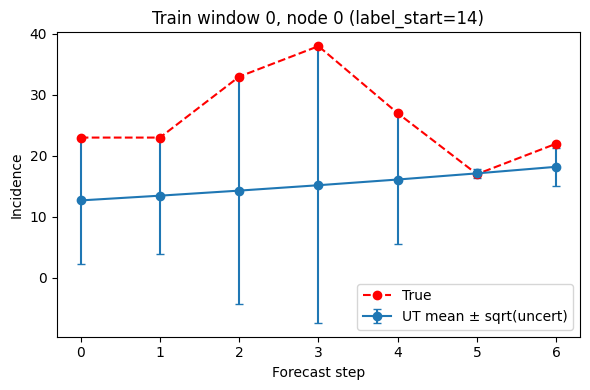


Train window 1 (label_start=15):
  y_future true  : [23. 33. 38. 27. 17. 22. 22.]
  y_hat (node 0) : [17.52336901 18.88488226 20.35628005 21.93880847 23.66640736 25.53119562
 27.54471804]
  uncert (node 0): [ 31.97117706 199.5831978  305.25714352  21.95435868  53.33748946
  19.74183318  45.60814795]


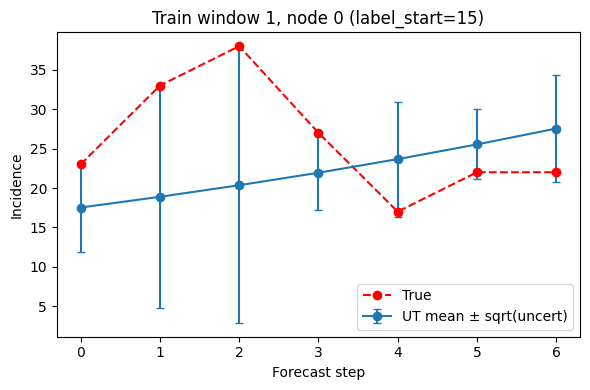

In [4]:
# inspect_ut_outputs.py

import numpy as np
import matplotlib.pyplot as plt

def inspect_npz(path: str, num_print: int = 2, visualize: bool = True):
    """
    Inspect the saved UT forecast + uncertainty file and visualize.

    Args:
        path: str, path to .npz file
        num_print: int, how many windows to print as examples
        visualize: bool, whether to plot curves
    """
    data = np.load(path, allow_pickle=True)
    print(f"Loaded keys: {list(data.keys())}\n")

    y_hat_all = data["y_hat_all"]        # (N_all, V, T_p)
    uncert_train = data["uncert_train"]  # (N_tr, V, T_p)
    y_future_train = data["y_future_train"]  # (N_tr, V, T_p)
    label_starts_all = data["label_starts_all"]
    label_starts_train = data["label_starts_train"]
    meta = data["meta"].item()           # dict

    print("Shapes:")
    print(f"  y_hat_all:        {y_hat_all.shape}")
    print(f"  uncert_train:     {uncert_train.shape}")
    print(f"  y_future_train:   {y_future_train.shape}")
    print(f"  label_starts_all: {label_starts_all.shape}")
    print(f"  label_starts_train: {label_starts_train.shape}")
    print(f"  meta: {meta}\n")

    # Show a few examples
    print(f"=== Example {num_print} train windows ===")
    for i in range(min(num_print, len(label_starts_train))):
        idx = i
        print(f"\nTrain window {i} (label_start={label_starts_train[idx]}):")
        print("  y_future true  :", y_future_train[idx, 0, :])   # show node 0
        print("  y_hat (node 0) :", y_hat_all[idx, 0, :])
        print("  uncert (node 0):", uncert_train[idx, 0, :])

        if visualize:
            steps = np.arange(y_future_train.shape[-1])
            y_true = y_future_train[idx, 0, :]
            y_hat = y_hat_all[idx, 0, :]
            u = uncert_train[idx, 0, :]

            plt.figure(figsize=(6, 4))
            plt.errorbar(
                steps, y_hat, yerr=np.sqrt(np.maximum(u, 0.0)),
                fmt='-o', capsize=3, label="UT mean ± sqrt(uncert)"
            )
            plt.plot(steps, y_true, 'r--o', label="True")
            plt.xlabel("Forecast step")
            plt.ylabel("Incidence")
            plt.title(f"Train window {i}, node 0 (label_start={label_starts_train[idx]})")
            plt.legend()
            plt.tight_layout()
            plt.show()

if __name__ == "__main__":
    PATH = "./ut_forecast_all_yhat_and_train_uncert_th14_tp7_test400.npz"
    inspect_npz(PATH, num_print=2, visualize=True)